# Supervised — KNN, SVM, Random Forest, MLP on colour features

Classical classifiers on hand-crafted colour descriptors. The baseline arm: how
much of the pH signal is plain colour statistics, before any deep model?

**Everything is scored per image.** The split is *grouped* by physical well, so
no well appears in both train and test, but accuracy is measured on individual
photographs.

In [1]:
import csv, warnings
import numpy as np, cv2
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
warnings.filterwarnings("ignore"); plt.rcParams["figure.dpi"]=110
SEED=42; CLASSES=[5,6,7,8]

rows=list(csv.DictReader(open("preprocessing/splits.csv")))
y=np.array([CLASSES.index(int(r["pH"])) for r in rows])
well=np.array([f'{r["pH"]}_{r["well"]}' for r in rows])
print(f"{len(rows)} images, {len(set(well))} physical wells")

2091 images, 192 physical wells


## Features — joint 8×8×8 HSV histogram

A *joint* 3D histogram, not three separate 1D ones: it keeps hue–saturation–value
co-occurrence, which marginal histograms throw away. 512 bins, L2-normalised.

241 of the 512 bins are identically zero across the dataset, so a variance
filter drops them before any distance-based model; 169 live features remain.

In [2]:
CACHE="supervised/_features.npz"
try:
    X=np.load(CACHE)["X"]; print("loaded cached features", X.shape)
except FileNotFoundError:
    def extract(p):
        img=cv2.resize(cv2.imread(p),(128,128))
        hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
        h=cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
        return cv2.normalize(h,h).flatten()
    X=np.array([extract(r["path"]) for r in rows],np.float32)
    np.savez_compressed(CACHE,X=X); print("built features", X.shape)
print("all-zero bins:", int((X.max(0)==0).sum()), "of", X.shape[1])

loaded cached features (2091, 512)
all-zero bins: 240 of 512


## Rule-based baselines (no training)

Two hand-written classifiers that threshold green intensity directly. They set
the floor a learned model needs to clear. Their thresholds are fixed constants
rather than fitted, so these are whole-dataset numbers.

In [3]:
def green_shade_vote(img):
    b,g,r=(img[:,:,i].astype(int) for i in range(3))
    green=(g>r)&(g>b)
    c={8:np.sum(green&(g<80)&(r<70)&(b<70)),
       7:np.sum(green&(g>=80)&(g<130)&(r<100)&(b<100)),
       6:np.sum(green&(g>=130)&(g<180)&(r<130)&(b<130)),
       5:np.sum(green&(g>=180)&(r<170)&(b<170))}
    return max(c,key=c.get)

def mean_green_threshold(img):
    m=img.sum(2)>15
    mg=img[:,:,1][m].mean() if m.any() else 0
    return 5 if mg<60 else 6 if mg<75 else 7 if mg<90 else 8

true=[];p1=[];p2=[]
for r in rows:
    im=cv2.resize(cv2.imread(r["path"]),(128,128))
    true.append(int(r["pH"])); p1.append(green_shade_vote(im)); p2.append(mean_green_threshold(im))
true=np.array(true)
base=max(Counter(true).values())/len(true)
print(f"majority baseline           {base:.3f}")
print(f"green-shade pixel voting    {accuracy_score(true,p1):.3f}")
print(f"mean-green threshold        {accuracy_score(true,p2):.3f}")
print()
print(f"Both sit at or below the majority baseline. The threshold rule collapses,")
print(f"predicting pH8 for {Counter(p2)[8]} of {len(p2)} images:")
print("    ", dict(Counter(p2)))
print()
print("Fixed colour thresholds carry little pH signal here, so the learned")
print("models below are not competing against a strong heuristic.")

majority baseline           0.252
green-shade pixel voting    0.162
mean-green threshold        0.252

Both sit at or below the majority baseline. The threshold rule collapses,
predicting pH8 for 2060 of 2091 images:
     {8: 2060, 7: 31}

Fixed colour thresholds carry little pH signal here, so the learned
models below are not competing against a strong heuristic.


## Trained classifiers

`StratifiedGroupKFold(5)` grouped by well — every well tested exactly once.
Hyperparameters come from a grid search on the held-out validation wells.

In [4]:
def cv(make, name, X=X):
    accs=[];f1s=[];bins=[];CM=np.zeros((4,4),int)
    for tr,te in StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(np.zeros(len(y)),y,groups=well):
        m=make().fit(X[tr],y[tr]); p=m.predict(X[te])
        accs.append(accuracy_score(y[te],p)); f1s.append(f1_score(y[te],p,average="macro"))
        bins.append(accuracy_score(y[te]>=2,p>=2)); CM+=confusion_matrix(y[te],p,labels=range(4))
    print(f"  {name:26s} acc {np.mean(accs):.3f} +/- {np.std(accs):.3f}   "
          f"macroF1 {np.mean(f1s):.3f}   acid/alk {np.mean(bins):.3f}")
    return dict(name=name,acc=np.mean(accs),std=np.std(accs),f1=np.mean(f1s),
                binary=np.mean(bins),cm=CM)

VT=lambda est: make_pipeline(VarianceThreshold(1e-8),StandardScaler(),est)
res=[]
res.append(cv(lambda: DummyClassifier(strategy="most_frequent"),"Baseline (majority)"))
res.append(cv(lambda: VT(MLPClassifier((64,64),alpha=0.1,max_iter=1000,early_stopping=True,random_state=SEED)),"MLP (64,64)"))
res.append(cv(lambda: VT(SVC(C=10,random_state=SEED)),"SVM (RBF, C=10)"))
res.append(cv(lambda: VT(KNeighborsClassifier(n_neighbors=9,metric="manhattan")),"KNN (k=9)"))
res.append(cv(lambda: RandomForestClassifier(400,min_samples_leaf=2,random_state=SEED,n_jobs=-1),"Random Forest"))

  Baseline (majority)        acc 0.231 +/- 0.009   macroF1 0.094   acid/alk 0.490


  MLP (64,64)                acc 0.680 +/- 0.032   macroF1 0.680   acid/alk 0.904


  SVM (RBF, C=10)            acc 0.726 +/- 0.016   macroF1 0.726   acid/alk 0.914
  KNN (k=9)                  acc 0.713 +/- 0.015   macroF1 0.714   acid/alk 0.920


  Random Forest              acc 0.762 +/- 0.031   macroF1 0.764   acid/alk 0.933


## Results

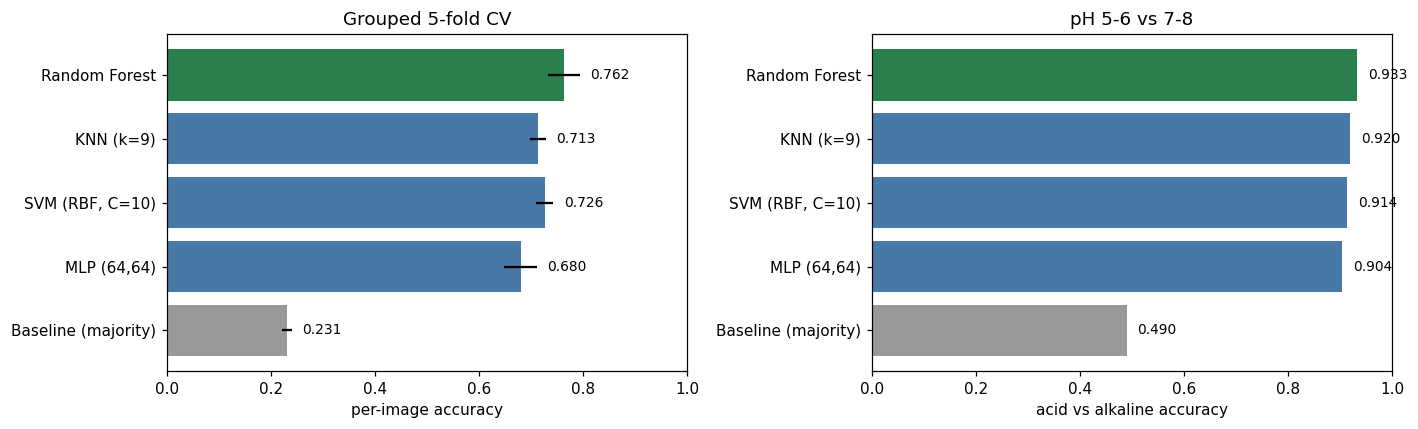

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
names=[r["name"] for r in res]; accs=[r["acc"] for r in res]; errs=[r["std"] for r in res]
cols=["#999"]+["#4878a8"]*3+["#2a7f4f"]
ax[0].barh(names,accs,xerr=errs,color=cols); ax[0].set_xlim(0,1)
ax[0].set_xlabel("per-image accuracy"); ax[0].set_title("Grouped 5-fold CV")
for i,(a,e) in enumerate(zip(accs,errs)): ax[0].text(a+e+.02,i,f"{a:.3f}",va="center",fontsize=9)
ax[1].barh(names,[r["binary"] for r in res],color=cols); ax[1].set_xlim(0,1)
ax[1].set_xlabel("acid vs alkaline accuracy"); ax[1].set_title("pH 5-6 vs 7-8")
for i,r in enumerate(res): ax[1].text(r["binary"]+.02,i,f"{r['binary']:.3f}",va="center",fontsize=9)
plt.tight_layout(); plt.show()

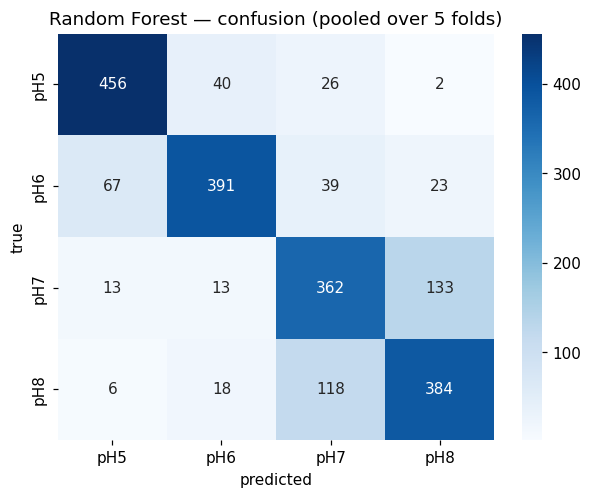

errors 498 of 2091, of which 140 cross the acid/alkaline boundary
Errors are almost entirely between ADJACENT pH values (5<->6, 7<->8).


In [6]:
best=res[-1]
sns.heatmap(best["cm"],annot=True,fmt="d",cmap="Blues",
            xticklabels=[f"pH{c}" for c in CLASSES], yticklabels=[f"pH{c}" for c in CLASSES])
plt.title(f"{best['name']} — confusion (pooled over 5 folds)")
plt.xlabel("predicted"); plt.ylabel("true"); plt.show()
cm=best["cm"]; cross=cm[:2,2:].sum()+cm[2:,:2].sum()
print(f"errors {cm.sum()-np.trace(cm)} of {cm.sum()}, of which {cross} cross the acid/alkaline boundary")
print("Errors are almost entirely between ADJACENT pH values (5<->6, 7<->8).")

## Train / validation / test breakdown

The cross-validated results above pool **held-out** predictions, so they say
nothing about the fit on training data. `preprocessing/splits.csv` also carries a
fixed 116 / 40 / 36-well holdout; fitting once on the train wells and scoring all
three splits shows the train-to-validation gap directly.

In [7]:
import pandas as pd
from IPython.display import display

sp=np.array([r["split"] for r in rows])
masks={"train":sp=="train","validation":sp=="val","test":sp=="test"}
fixed=RandomForestClassifier(400,min_samples_leaf=2,random_state=SEED,n_jobs=-1)
fixed.fit(X[masks["train"]],y[masks["train"]])

CMs={}; table=[]
for name,m in masks.items():
    p=fixed.predict(X[m]); CMs[name]=confusion_matrix(y[m],p,labels=range(4))
    table.append(dict(split=name, wells=len(set(well[m])), images=int(m.sum()),
                      accuracy=accuracy_score(y[m],p),
                      macro_F1=f1_score(y[m],p,average="macro"),
                      acid_vs_alkaline=accuracy_score(y[m]>=2,p>=2)))
df=pd.DataFrame(table).set_index("split").round(3)
display(df)
print(f"train -> validation gap: {df.loc['train','accuracy']-df.loc['validation','accuracy']:+.3f}")

,wells,images,accuracy,macro_F1,acid_vs_alkaline
split,,,,,
train,116,1264,1.000,1.000,1.000
validation,40,435,0.738,0.739,0.910
test,36,392,0.745,0.746,0.931


train -> validation gap: +0.262


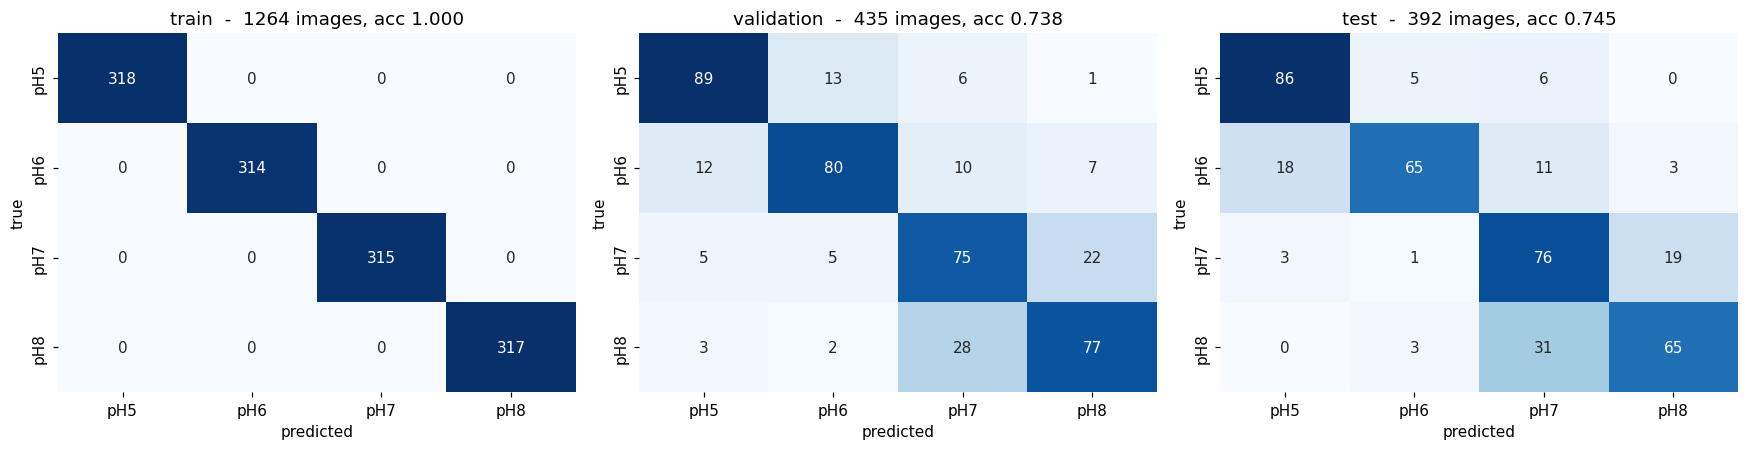

In [8]:
fig,ax=plt.subplots(1,3,figsize=(16,4.2))
for a,(name,cm) in zip(ax,CMs.items()):
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=a,cbar=False,
                xticklabels=[f"pH{c}" for c in CLASSES],yticklabels=[f"pH{c}" for c in CLASSES])
    a.set_title(f"{name}  -  {cm.sum()} images, acc {np.trace(cm)/cm.sum():.3f}")
    a.set_xlabel("predicted"); a.set_ylabel("true")
plt.tight_layout(); plt.show()

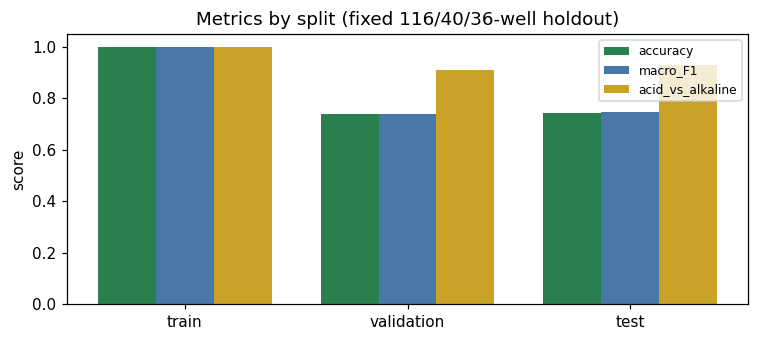

              precision    recall  f1-score   support

         pH5       0.82      0.82      0.82       109
         pH6       0.80      0.73      0.77       109
         pH7       0.63      0.70      0.66       107
         pH8       0.72      0.70      0.71       110

    accuracy                           0.74       435
   macro avg       0.74      0.74      0.74       435
weighted avg       0.74      0.74      0.74       435



In [9]:
fig,ax=plt.subplots(figsize=(7,3.2))
names=list(df.index); w=0.26; xs=np.arange(len(names))
for i,(col,c) in enumerate([("accuracy","#2a7f4f"),("macro_F1","#4878a8"),("acid_vs_alkaline","#c9a227")]):
    ax.bar(xs+(i-1)*w, df[col], w, label=col, color=c)
ax.set_xticks(xs); ax.set_xticklabels(names); ax.set_ylim(0,1.05)
ax.set_ylabel("score"); ax.set_title("Metrics by split (fixed 116/40/36-well holdout)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(classification_report(y[masks["validation"]],fixed.predict(X[masks["validation"]]),
                            target_names=[f"pH{c}" for c in CLASSES]))

The Random Forest fits the 116 training wells completely. The grid covered
`max_depth`, `min_samples_leaf` and `max_features`, and the most heavily
regularised settings did not improve validation accuracy — with 116 training
wells in 169 effective dimensions, the gap reflects the size of the dataset
rather than the choice of hyperparameters. Validation and test agree closely, so
the held-out estimate is stable. Nothing underfits: the majority baseline is
0.214 and every model sits far above it.

---
**Best in this folder: Random Forest, 0.755 per image, 0.931 acid-vs-alkaline.**

The best model overall is in `transfer_learning/` — this same histogram plus an
avg+std pooled ResNet18 **stem**, reaching 0.808.